We will start our analysis by importing the core libraries required for data manipulation and visualization.  Pandas and Numpy: Essential for structuring, manipulating, and performing numerical operations on our data.  Seaborn and Matplotlib: Powerful libraries for creating charts, graphs, and visual explorations of the dataset. 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Datasets often have many features, and Pandas will truncate the output by default to save space. To ensure we can easily inspect our data, we will adjust the Pandas display options to show up to 30 columns and 500 rows at a time.

In [2]:
pd.set_option('display.max_columns',30)
pd.set_option('display.max_rows',500)


Next, we will load our raw data into a Pandas DataFrame. The dataset we are analyzing is located in our raw data folder under the name cc_defaults.csv. (Note: The .head() and .info() commands are currently commented out, but they are great tools to quickly preview the loaded data)

In [3]:
df=pd.read_csv('../data/raw/cc_defaults.csv')
# display(df.head())
# display(df.info())

Before training any models, it is crucial to understand the shape, distribution, and completeness of our data. In this step, we will run a comprehensive check on the dataset:
1. Statistical Summary: We generate a statistical breakdown (mean, standard deviation, min/max values) for all 30,000 records.
2. Missing Values: We check every column to see if there is any missing data. Fortunately, this dataset is perfectly clean, with 0 missing values across all columns.
3. Target Variable Analysis: We isolate our target variable, default.payment.next.month, to see the balance of our classes. Out of 30,000 customers, 6,636 (22.12%) defaulted, while 23,364 (77.88%) did not.

In [5]:
# 1. Statistical summary of all columns
print("=== STATISTICAL SUMMARY ===")
display(df.describe())

# 2. Check for missing values
print("\n=== MISSING VALUES PER COLUMN ===")
display(df.isnull().sum())

# 3. Target Variable Analysis
# Automatically find the target column (usually 'default.payment.next.month')
target_col = [col for col in df.columns if 'default' in col.lower()][0]

print(f"\n=== TARGET COLUMN: {target_col} ===")
print("Raw Counts:")
display(df[target_col].value_counts())

print("\nPercentages:")
display(df[target_col].value_counts(normalize=True) * 100)

=== STATISTICAL SUMMARY ===


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000



=== MISSING VALUES PER COLUMN ===


ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


=== TARGET COLUMN: default.payment.next.month ===
Raw Counts:


default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


Percentages:


default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64

To get a better sense of our class imbalance, we will visualize the distribution of our target variable using a Seaborn count plot.

Note on Seaborn Updates: If you see a FutureWarning in the output, it is simply because newer versions of Seaborn require assigning the x variable to hue when using a specific palette. This does not affect the validity of our plot.

/tmp/ipykernel_5046/2302481310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[0], palette='viridis')


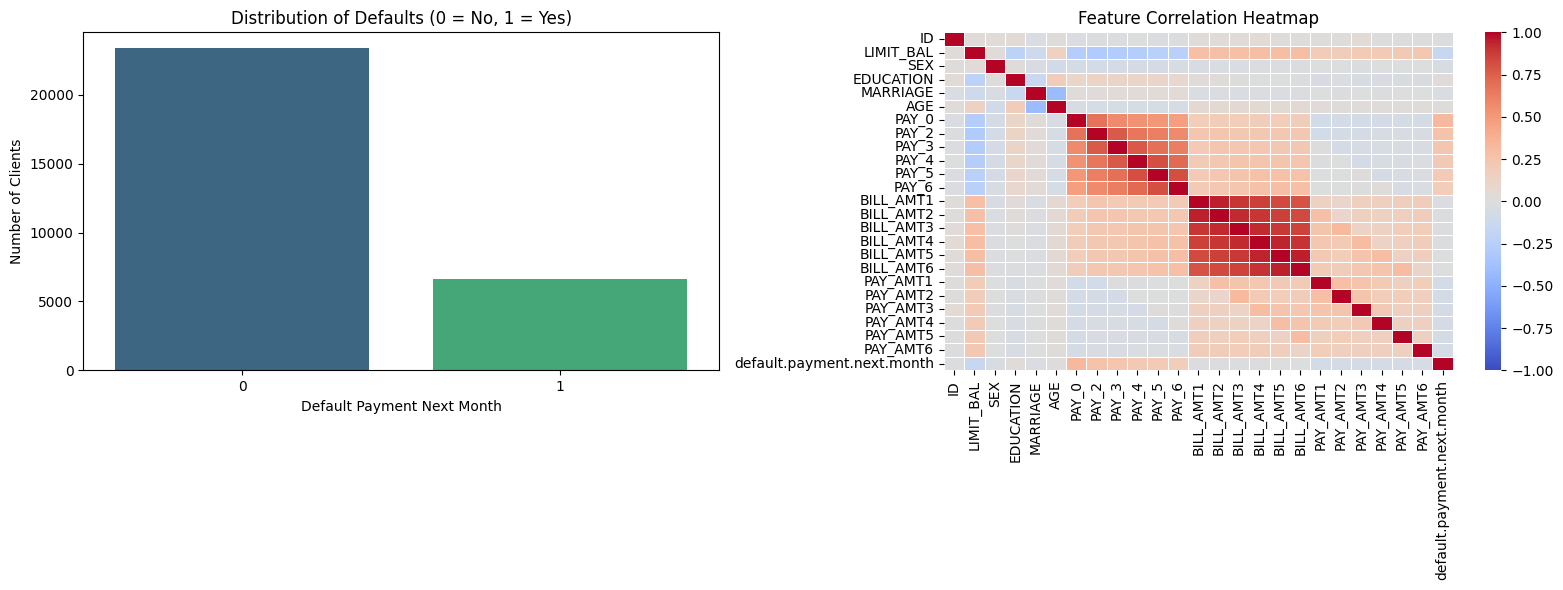

In [6]:
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Target Distribution
sns.countplot(data=df, x=target_col, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Defaults (0 = No, 1 = Yes)')
axes[0].set_xlabel('Default Payment Next Month')
axes[0].set_ylabel('Number of Clients')

# Chart 2: Correlation Heatmap
# We'll calculate the correlation matrix for all columns
corr_matrix = df.corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, ax=axes[1], cmap='coolwarm', annot=False, fmt=".1f", linewidths=.5, vmin=-1, vmax=1, center=0)
axes[1].set_title('Feature Correlation Heatmap')

# Display the plots
plt.tight_layout()
plt.show()

In [4]:
df['EDUCATION']=df['EDUCATION'].replace([0,5,6],4)

In [5]:
df['MARRIAGE']=df['MARRIAGE'].replace(0,3)

In [6]:
from sklearn.model_selection import train_test_split

# 1. Drop the ID column
df_clean = df.drop('ID', axis=1)

# 2. Separate X (Features) and y (Target)
X = df_clean.drop('default.payment.next.month', axis=1)
y = df_clean['default.payment.next.month']

# 3. First Split: Carve out 20% for the final Test Set
# This leaves 80% in "temp" (which we will split again)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Second Split: Split the remaining 80% into Train and Validation
# If we want 20% of the TOTAL data for validation, that is exactly 25% (0.25) of the 80% we have left.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("=== 3-WAY DATA SPLIT SUCCESSFUL ===")
print(f"X_train shape (Training):   {X_train.shape} - 60%")
print(f"X_val shape   (Validation): {X_val.shape} - 20%")
print(f"X_test shape  (Testing):    {X_test.shape} - 20%")

=== 3-WAY DATA SPLIT SUCCESSFUL ===
X_train shape (Training):   (18000, 23) - 60%
X_val shape   (Validation): (6000, 23) - 20%
X_test shape  (Testing):    (6000, 23) - 20%


In [8]:
# Print the original row numbers for the first 5 rows in X_train
print("X_train row numbers:")
print(X_train.head().index)

# Print the original row numbers for the first 5 rows in y_train
print("\ny_train row numbers:")
print(y_train.head().index)

X_train row numbers:
Index([10574, 11330, 7127, 25150, 6000], dtype='int64')

y_train row numbers:
Index([10574, 11330, 7127, 25150, 6000], dtype='int64')


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the Random Forest (We will use 100 decision trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model (This is where the AI actually learns the patterns!)
print("Training the Random Forest...")
rf_model.fit(X_train, y_train)

# 3. Give the AI its first test using the Validation data
y_val_rf_pred = rf_model.predict(X_val)


from sklearn.metrics import classification_report, confusion_matrix

# Print the detailed report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_val_rf_pred))

# Print the raw matrix numbers
print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_val, y_val_rf_pred))

# 4. Grade the test
val_accuracy = accuracy_score(y_val, y_val_rf_pred)

print("=== AI TRAINING COMPLETE ===")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Training the Random Forest...
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000


=== CONFUSION MATRIX ===
[[4430  243]
 [ 863  464]]
=== AI TRAINING COMPLETE ===
Validation Accuracy: 81.57%


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Re-initialize the model with class_weight='balanced'
rf_balanced = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',  # <--- THIS IS THE MAGIC KNOB
    random_state=42
)

# 2. Retrain on training data
rf_balanced.fit(X_train, y_train)

# 3. Predict on Validation data
y_val_rf_pred_balanced = rf_balanced.predict(X_val)

# 4. Print results
print("=== BALANCED RANDOM FOREST REPORT ===")
print(classification_report(y_val, y_val_rf_pred_balanced))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_val, y_val_rf_pred_balanced))

=== BALANCED RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.66      0.33      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000


=== CONFUSION MATRIX ===
[[4446  227]
 [ 892  435]]


In [9]:
import numpy as np

# 1. Ask the AI for the PROBABILITY of default, not just the final vote
# (This returns a list of percentages, like 0.15, 0.82, 0.31...)
probabilities = rf_balanced.predict_proba(X_val)[:, 1]

# 2. OVERRIDE: Set our own strict banking threshold at 30%
threshold = 0.30
y_val_rf_pred_custom = (probabilities >= threshold).astype(int)

# 3. Print the new results
print(f"=== RESULTS WITH BALANCED {threshold*100}% THRESHOLD ===")
print(classification_report(y_val, y_val_rf_pred_custom))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_val, y_val_rf_pred_custom))

=== RESULTS WITH BALANCED 30.0% THRESHOLD ===
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.51      0.54      0.52      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.79      6000


=== CONFUSION MATRIX ===
[[3992  681]
 [ 616  711]]


In [13]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("1. Generating synthetic defaulters to balance the data...")
smote = SMOTE(random_state=42)

# We ONLY apply SMOTE to the training data!
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("2. Training a fresh AI on the new 50/50 dataset...")
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

print("3. Testing the AI on the pristine Validation data...")
y_val_rf_pred_smote = rf_smote.predict(X_val)

print("\n=== SMOTE RANDOM FOREST REPORT ===")
print(classification_report(y_val, y_val_rf_pred_smote))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_val, y_val_rf_pred_smote))

import numpy as np

# 1. Ask the AI for the PROBABILITY of default, not just the final vote
# (This returns a list of percentages, like 0.15, 0.82, 0.31...)
probabilities = rf_smote.predict_proba(X_val)[:, 1]

# 2. OVERRIDE: Set our own strict banking threshold at 30%
threshold = 0.35
y_val_rf_pred_smote_custom = (probabilities >= threshold).astype(int)

# 3. Print the new results
print(f"=== SMOTE RANDOM FOREST REPORT RESULTS WITH {threshold*100}% THRESHOLD ===")
print(classification_report(y_val, y_val_rf_pred_smote_custom))

print("\n=== SMOTE RANDOM FOREST CONFUSION MATRIX ===")
print(confusion_matrix(y_val, y_val_rf_pred_smote_custom))

1. Generating synthetic defaulters to balance the data...
2. Training a fresh AI on the new 50/50 dataset...
3. Testing the AI on the pristine Validation data...

=== SMOTE RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4673
           1       0.53      0.49      0.51      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.68      0.69      6000
weighted avg       0.78      0.79      0.79      6000


=== CONFUSION MATRIX ===
[[4090  583]
 [ 680  647]]
=== SMOTE RANDOM FOREST REPORT RESULTS WITH 35.0% THRESHOLD ===
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      4673
           1       0.40      0.68      0.51      1327

    accuracy                           0.70      6000
   macro avg       0.64      0.70      0.65      6000
weighted avg       0.78      0.70      0.73      6000


=== SMOTE RANDOM FOREST CONFUS

In [14]:
display(df['SEX'].value_counts())
display(df['EDUCATION'].value_counts())
display(df['MARRIAGE'].value_counts())

SEX
2    18112
1    11888
Name: count, dtype: int64

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define the useless columns to drop (the bottom 5 from our brain scan)
columns_to_drop = ['SEX', 'EDUCATION', 'MARRIAGE']

# 2. Drop them from both Training and Validation sets
X_train_pruned = X_train.drop(columns=columns_to_drop)
X_val_pruned = X_val.drop(columns=columns_to_drop)

print(f"Old number of columns: {X_train.shape[1]}")
print(f"New number of columns: {X_train_pruned.shape[1]}")

# 3. Apply SMOTE to the clean, pruned training data
smote_pruned = SMOTE(random_state=42)
X_train_smote_pruned, y_train_smote_pruned = smote_pruned.fit_resample(X_train_pruned, y_train)

# 4. Train a new Random Forest on the pruned data
rf_pruned = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pruned.fit(X_train_smote_pruned, y_train_smote_pruned)

# 5. Test it on the pruned Validation data
y_val_pred_pruned = rf_pruned.predict(X_val_pruned)

# 6. Print the results
print("\n=== PRUNED SMOTE RANDOM FOREST REPORT ===")
print(classification_report(y_val, y_val_pred_pruned))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_val, y_val_pred_pruned))

Old number of columns: 23
New number of columns: 20

=== PRUNED SMOTE RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      4673
           1       0.53      0.46      0.50      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.67      0.68      6000
weighted avg       0.78      0.79      0.79      6000


=== CONFUSION MATRIX ===
[[4132  541]
 [ 711  616]]


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Create ALL dummy columns without dropping anything initially
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_cols)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)

# 2. Align them to ensure identical structures
X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)

# 3. Manually drop your chosen baselines (Strict mode - no safety net!)
# Assuming category '4' is your 'Other' for Education
columns_to_hide = ['SEX_1', 'EDUCATION_4', 'MARRIAGE_3'] 
X_train_encoded = X_train_encoded.drop(columns=columns_to_hide)
X_val_encoded = X_val_encoded.drop(columns=columns_to_hide)
X_test_encoded = X_test_encoded.drop(columns=columns_to_hide)

print("Custom One-Hot Encoding complete!")

# 4. Standardize the scale of the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Old Training Shape: {X_train.shape}")
print(f"New Training Shape: {X_train_scaled.shape}")
print(f"Old Validation Shape: {X_val.shape}")
print(f"New validation Shape: {X_val_scaled.shape}")
print(f"Old Test Shape: {X_test.shape}")
print(f"New Test Shape: {X_test_scaled.shape}")
print("Data is now physically ready for the SVM.")

Custom One-Hot Encoding complete!
Old Training Shape: (18000, 23)
New Training Shape: (18000, 26)
Old Validation Shape: (6000, 23)
New validation Shape: (6000, 26)
Old Test Shape: (6000, 23)
New Test Shape: (6000, 26)
Data is now physically ready for the SVM.


In [15]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

print("Training the Support Vector Machine (SVM)... grab a coffee, this might take a minute!")

# 1. Initialize the SVM
# kernel='rbf' allows it to draw curved, non-linear boundaries
# class_weight='balanced' penalizes it heavily if it misses defaulters
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# 2. Train the model using our SCALED data
svm_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the SCALED validation data
y_val_pred_svm = svm_model.predict(X_val_scaled)

# 4. Print the results
print("\n=== SVM CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_val_pred_svm))

print("\n=== SVM CONFUSION MATRIX ===")
print(confusion_matrix(y_val, y_val_pred_svm))

Training the Support Vector Machine (SVM)... grab a coffee, this might take a minute!

=== SVM CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000


=== SVM CONFUSION MATRIX ===
[[3914  759]
 [ 574  753]]


In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("Moving the SVM decision boundary into 'Safe Land'...")

# 1. Get the raw distance scores (our GPS tracker)
y_scores_svm = svm_model.decision_function(X_val_scaled)

display(pd.Series(y_scores_svm).describe())

Moving the SVM decision boundary into 'Safe Land'...


count    6000.000000
mean       -0.451059
std         0.835383
min        -1.806129
25%        -1.018332
50%        -0.883262
75%         0.018571
max         2.509364
dtype: float64

In [14]:
# 2. Shift the wall backwards. 
# 0.0 is the default. Let's try -0.36 to catch people hovering near the border.
aggressive_threshold = -0.36

# 3. Create new predictions: Flag anyone greater than -0.36
y_pred_svm_aggressive = (y_scores_svm >= aggressive_threshold).astype(int)

# 4. Print the results
print(f"The new boundary is set at distance: {aggressive_threshold}")
print(f"\n=== SVM (AGGRESSIVE CUTOFF: {aggressive_threshold}) ===")
print(classification_report(y_val, y_pred_svm_aggressive))

print("\n=== SVM CONFUSION MATRIX (AGGRESSIVE CUTOFF) ===")
print(confusion_matrix(y_val, y_pred_svm_aggressive))

The new boundary is set at distance: -0.36

=== SVM (AGGRESSIVE CUTOFF: -0.36) ===
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4673
           1       0.46      0.61      0.52      1327

    accuracy                           0.75      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.75      0.76      6000


=== SVM CONFUSION MATRIX (AGGRESSIVE CUTOFF) ===
[[3703  970]
 [ 515  812]]


Below cnippet require high RAM as it runs multiple models together.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define the grid of settings we want to test
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01]
}

# 2. Set up the Grid Search
# cv=3 means it double-checks its work 3 times per combination
# scoring='f1' tells it to only care about getting the highest F1-score
# verbose=2 will print out progress updates so you know it hasn't frozen
# n_jobs=-1 tells your computer to use all its CPU cores to go faster
grid_search = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

print("Starting Grid Search... grab a snack, this will take a while!")
grid_search.fit(X_train_scaled, y_train)

# 3. Print the winning settings
print("\n=== GRID SEARCH COMPLETE ===")
print(f"Best Parameters found: {grid_search.best_params_}")

# 4. Automatically use the best model to make predictions on validation data
best_svm = grid_search.best_estimator_
y_val_pred_best = best_svm.predict(X_val_scaled)

print("\n=== TUNED SVM CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_val_pred_best))

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# 1. Define hyperparameter grid
C_options = [0.1, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 10]
gamma_options = ['scale', 0.01]

best_cv_f1 = 0
best_params = {}

print("Starting Sequential 3-Fold Cross-Validation (RAM-Safe Mode)...\n")

# 2. Iterate through parameters sequentially
for c in C_options:
    for g in gamma_options:
        print(f"Evaluating C={c}, gamma={g} across 3 folds...")
        
        # Define model instance
        model = SVC(kernel='rbf', C=c, gamma=g, class_weight='balanced', random_state=42)
        
        # Run 3-fold CV strictly on single thread (n_jobs=1) to prevent RAM spikes
        scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=1)
        mean_f1 = np.mean(scores)
        
        print(f"--> Mean 3-Fold F1-Score: {mean_f1:.4f}\n")
        
        # Track highest average F1 score
        if mean_f1 > best_cv_f1:
            best_cv_f1 = mean_f1
            best_params = {'C': c, 'gamma': g}

print("=== 3-FOLD CROSS-VALIDATION COMPLETE ===")
print(f"Best Parameters: {best_params}")
print(f"Best 3-Fold CV F1-Score: {best_cv_f1:.4f}\n")

# 3. Train final model on 100% of training data using the best parameters
print("Training final tuned model on full training set...")
final_svm = SVC(
    kernel='rbf', 
    C=best_params['C'], 
    gamma=best_params['gamma'], 
    class_weight='balanced', 
    random_state=42
)
final_svm.fit(X_train_scaled, y_train)

# 4. Evaluate on validation set
y_val_pred_tuned = final_svm.predict(X_val_scaled)
print("\n=== TUNED SVM VALIDATION REPORT ===")
print(classification_report(y_val, y_val_pred_tuned))

Starting Sequential 3-Fold Cross-Validation (RAM-Safe Mode)...

Evaluating C=0.1, gamma=scale across 3 folds...
--> Mean 3-Fold F1-Score: 0.5297

Evaluating C=0.1, gamma=0.01 across 3 folds...
--> Mean 3-Fold F1-Score: 0.5240

Evaluating C=1, gamma=scale across 3 folds...
--> Mean 3-Fold F1-Score: 0.5356

Evaluating C=1, gamma=0.01 across 3 folds...
--> Mean 3-Fold F1-Score: 0.5331

Evaluating C=1.2, gamma=scale across 3 folds...
--> Mean 3-Fold F1-Score: 0.5348

Evaluating C=1.2, gamma=0.01 across 3 folds...
--> Mean 3-Fold F1-Score: 0.5346

Evaluating C=1.4, gamma=scale across 3 folds...
--> Mean 3-Fold F1-Score: 0.5342

Evaluating C=1.4, gamma=0.01 across 3 folds...
--> Mean 3-Fold F1-Score: 0.5344

Evaluating C=1.6, gamma=scale across 3 folds...
--> Mean 3-Fold F1-Score: 0.5340

Evaluating C=1.6, gamma=0.01 across 3 folds...
--> Mean 3-Fold F1-Score: 0.5342

Evaluating C=1.8, gamma=scale across 3 folds...
--> Mean 3-Fold F1-Score: 0.5327

Evaluating C=1.8, gamma=0.01 across 3 folds

In [16]:
# 3. Train final model on 100% of training data using the best parameters
print("Training final tuned model on full training set...")
final_svm = SVC(
    kernel='rbf', 
    C=1, 
    gamma='scale', 
    class_weight='balanced', 
    random_state=42
)
final_svm.fit(X_train_scaled, y_train)

# 4. Evaluate on validation set
y_val_pred_tuned = final_svm.predict(X_val_scaled)
print("\n=== TUNED SVM VALIDATION REPORT ===")
print(classification_report(y_val, y_val_pred_tuned))

Training final tuned model on full training set...

=== TUNED SVM VALIDATION REPORT ===
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000



In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Scale the Test Set for distance-based models (SVM)
# X_test_scaled = scaler.transform(X_test)

# Storage for comparative metrics
test_summary = []

def get_metrics(model_name, y_true, y_pred):
    return {
        "Model Variant": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision (Class 1)": round(precision_score(y_true, y_pred), 4),
        "Recall (Class 1)": round(recall_score(y_true, y_pred), 4),
        "F1-Score (Class 1)": round(f1_score(y_true, y_pred), 4)
    }

# --- 1. Baseline Random Forest ---
y_pred_rf = rf_model.predict(X_test)
test_summary.append(get_metrics("Baseline Random Forest", y_test, y_pred_rf))

# --- 2. Balanced Random Forest ---
y_pred_rf_bal = rf_balanced.predict(X_test)
test_summary.append(get_metrics("Balanced Random Forest", y_test, y_pred_rf_bal))

# --- 3. Balanced Random Forest (30% Probability Threshold) ---
rf_probs = rf_balanced.predict_proba(X_test)[:, 1]
y_pred_rf_bal_30 = (rf_probs >= 0.30).astype(int)
test_summary.append(get_metrics("Bal_RF (30% Threshold)", y_test, y_pred_rf_bal_30))

# --- 4. SMOTE Random Forest ---
y_pred_smote = rf_smote.predict(X_test)
test_summary.append(get_metrics("SMOTE Random Forest", y_test, y_pred_smote))

# --- 5. SMOTE Random Forest (30% Probability Threshold) ---
smote_probs = rf_smote.predict_proba(X_test)[:, 1]
y_pred_smote_30 = (smote_probs >= 0.30).astype(int)
test_summary.append(get_metrics("SMOTE RF (30% Threshold)", y_test, y_pred_smote_30))

# --- 6. SVM (C=1, gamma='scale') ---
y_pred_svm = svm_model.predict(X_test_scaled)
test_summary.append(get_metrics("RBF SVM", y_test, y_pred_svm))

# --- 7. SVM (Aggressive -0.36 Cutoff) ---
svm_scores = svm_model.decision_function(X_test_scaled)
y_pred_svm_agg = (svm_scores >= -0.36).astype(int)
test_summary.append(get_metrics("RBF SVM (-0.36 Cutoff)", y_test, y_pred_svm_agg))

# --- 8. Tuned SVM (C=1, gamma='scale') ---
y_pred_svm_tuned = final_svm.predict(X_test_scaled)
test_summary.append(get_metrics("Tuned RBF SVM", y_test, y_pred_svm_tuned))

# --- 9. Tuned SVM (Aggressive -0.36 Cutoff) ---
svm_scores = final_svm.decision_function(X_test_scaled)
y_pred_svm_tuned_agg = (svm_scores >= -0.36).astype(int)
test_summary.append(get_metrics("Tuned SVM (-0.36 Cutoff)", y_test, y_pred_svm_tuned_agg))

# --- Final Comparison Table ---
comparison_df = pd.DataFrame(test_summary)
print("=========================================================================")
print("                       FINAL UNSEEN TEST SET RESULTS                     ")
print("=========================================================================")
print(comparison_df.to_string(index=False))

                       FINAL UNSEEN TEST SET RESULTS                     
           Model Variant  Accuracy  Precision (Class 1)  Recall (Class 1)  F1-Score (Class 1)
  Baseline Random Forest    0.8152               0.6449            0.3655              0.4666
  Balanced Random Forest    0.8118               0.6439            0.3338              0.4397
  Bal_RF (30% Threshold)    0.7848               0.5131            0.5305              0.5217
     SMOTE Random Forest    0.7872               0.5201            0.4883              0.5037
SMOTE RF (30% Threshold)    0.6425               0.3513            0.7280              0.4739
                 RBF SVM    0.7755               0.4933            0.5584              0.5239
  RBF SVM (-0.36 Cutoff)    0.7458               0.4447            0.5998              0.5107
           Tuned RBF SVM    0.7755               0.4933            0.5584              0.5239
Tuned SVM (-0.36 Cutoff)    0.7458               0.4447            0.5998       

In [18]:
import joblib

# Save model and preprocessor
joblib.dump(final_svm, 'final_tuned_svm_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
print("Model and Scaler successfully exported for deployment!")

Model and Scaler successfully exported for deployment!


In [9]:
import joblib

# Extract the exact column names the model was trained on
expected_columns = list(X_train_encoded.columns) 

# Save the list to disk
joblib.dump(expected_columns, 'expected_columns.pkl')

print("Expected columns successfully saved!")

Expected columns successfully saved!
